In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("datos/datos.csv")

In [4]:
df.head()
df.describe()

,appid,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,copiessold,revenue,firstreleasedate,reviewscore
count,2.323000e+04,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,2.323000e+04,2.323000e+04,2.323000e+04,23230.000000
mean,5.916447e+05,0.294791,38.654283,357.344727,82.258674,107.152217,112.587000,5.886544,6.482484e+04,2.605762e+05,1.481585e+12,70.916746
std,2.486956e+05,2.185441,310.533420,2653.099238,729.596943,1714.138494,2066.700829,6.258438,5.067301e+05,1.087396e+06,6.529230e+10,20.940744
min,2.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,9.229428e+11,0.000000
25%,3.978025e+05,0.000000,0.000000,6.000000,2.000000,0.000000,0.000000,1.690000,5.400000e+02,5.640000e+02,1.455512e+12,59.000000
50%,5.908300e+05,0.000000,8.000000,24.000000,8.000000,0.000000,0.000000,3.990000,3.213000e+03,5.133000e+03,1.499314e+12,75.000000
75%,7.908475e+05,0.000000,23.000000,118.000000,37.000000,0.000000,0.000000,7.190000,1.898500e+04,4.965075e+04,1.527134e+12,87.000000
max,1.069460e+06,18.000000,9821.000000,292574.000000,91664.000000,190625.000000,190625.000000,154.990000,5.355018e+07,1.229418e+07,1.682482e+12,100.000000


In [5]:
df.isnull().sum()

appid                0
nombre               0
release_date         0
english              0
developer            1
publisher           12
publisherclass       0
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
copiessold           0
revenue              0
unreleased           0
earlyaccess          0
firstreleasedate     0
reviewscore          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23230 entries, 0 to 23229
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             23230 non-null  int64  
 1   nombre            23230 non-null  object 
 2   release_date      23230 non-null  object 
 3   english           23230 non-null  object 
 4   developer         23229 non-null  object 
 5   publisher         23218 non-null  object 
 6   publisherclass    23230 non-null  object 
 7   platforms         23230 non-null  object 
 8   required_age      23230 non-null  int64  
 9   categories        23230 non-null  object 
 10  genres            23230 non-null  object 
 11  steamspy_tags     23230 non-null  object 
 12  achievements      23230 non-null  int64  
 13  positive_ratings  23230 non-null  int64  
 14  negative_ratings  23230 non-null  int64  
 15  average_playtime  23230 non-null  int64  
 16  median_playtime   23230 non-null  int64 

In [7]:
print(f"Cantidad de filas antes del drop: {len(df)}")
df = df.drop_duplicates()
print(f"Cantidad de filas después del drop: {len(df)}")

Cantidad de filas antes del drop: 23230
Cantidad de filas después del drop: 23230


In [8]:
X = df.drop(columns=["copiessold"]).copy()
y = df["copiessold"].copy()

print("Dimensiones (filas, columnas):", df.shape)
df.head()


Dimensiones (filas, columnas): (23230, 25)


,appid,nombre,release_date,english,developer,publisher,publisherclass,platforms,required_age,categories,...,average_playtime,median_playtime,owners,price,copiessold,revenue,unreleased,earlyaccess,firstreleasedate,reviewscore
0,20,Team Fortress Classic,1999-04-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,...,277,62,5000000-10000000,3.99,385769,862278,False,False,922942800000,87
1,30,Day of Defeat,2003-05-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,...,187,34,5000000-10000000,3.99,234765,500723,False,False,1051761600000,90
2,40,Deathmatch Classic,2001-06-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,...,258,184,5000000-10000000,3.99,146340,312387,False,False,991368000000,83
3,50,Half-Life: Opposing Force,1999-11-01,t,Gearbox Software,Valve,AAA,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,...,624,415,5000000-10000000,3.99,815610,1641208,False,False,941432400000,95
4,60,Ricochet,2000-11-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Valve Anti-Ch...,...,175,10,5000000-10000000,3.99,289530,619066,False,False,973054800000,83


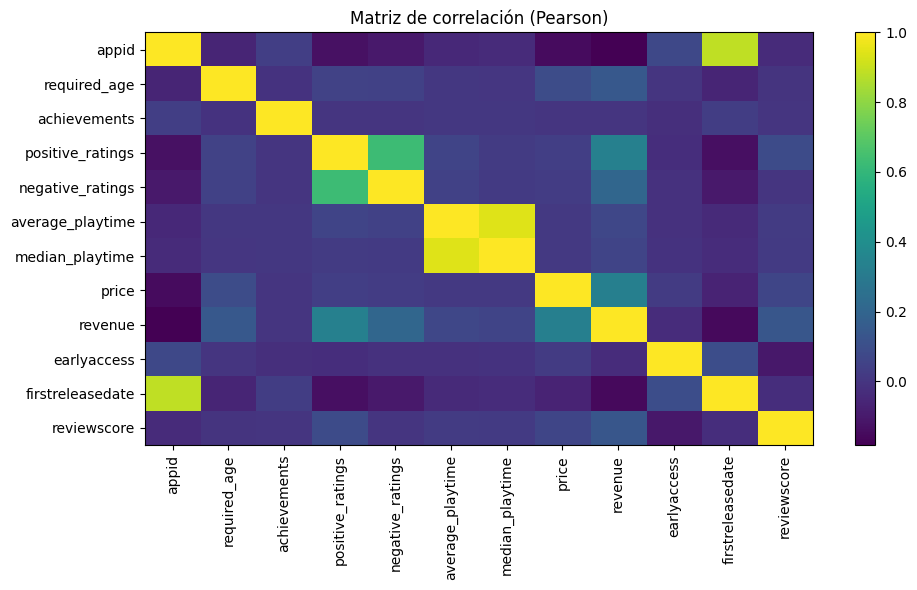

In [9]:
X = X.drop(columns=["unreleased"])
corr = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()


In [10]:
columnas_cuantitativas = ["price", "revenue", "required_age", "achievements", "positive_ratings", "negative_ratings", "average_playtime", "median_playtime", "price", "firstreleasedate", "reviewscore"]
columnas_lista = ["genres", "categories"]
columns_to_drop_cualitativo = ["nombre", "owners", "appid", "developer", "publisher", "steamspy_tags", "earlyaccess", "platforms"]

df_cuantitativo = X[columnas_cuantitativas].copy()
df_lista = X[columnas_lista].copy()
df_cualitativo = X.drop(columns=columnas_cuantitativas+columnas_lista+columns_to_drop_cualitativo + list(df_lista.columns)).copy()
df_cualitativo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23230 entries, 0 to 23229
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   release_date    23230 non-null  object
 1   english         23230 non-null  object
 2   publisherclass  23230 non-null  object
dtypes: object(3)
memory usage: 544.6+ KB


In [11]:
from sklearn.preprocessing import MultiLabelBinarizer

df_binarizado_total = pd.DataFrame()

for columna in columnas_lista:
    listas = df_lista[columna].fillna('').str.split(';')
    mlb = MultiLabelBinarizer()
    datos_binarizados = mlb.fit_transform(listas)
    df_temp = pd.DataFrame(datos_binarizados,
                           columns=mlb.classes_,
                           index=df_lista.index).add_prefix(f'{columna}_')
    df_binarizado_total = pd.concat([df_binarizado_total, df_temp], axis=1)

generos_binarizados = mlb.fit_transform(df_lista)

print("Vista previa del DataFrame binarizado final:")
print(df_binarizado_total.head())

Vista previa del DataFrame binarizado final:
   genres_Accounting  genres_Action  genres_Adventure  \
0                  0              1                 0   
1                  0              1                 0   
2                  0              1                 0   
3                  0              1                 0   
4                  0              1                 0   

   genres_Animation & Modeling  genres_Audio Production  genres_Casual  \
0                            0                        0              0   
1                            0                        0              0   
2                            0                        0              0   
3                            0                        0              0   
4                            0                        0              0   

   genres_Design & Illustration  genres_Early Access  genres_Education  \
0                             0                    0                 0   
1                  

In [12]:
encoder = OneHotEncoder(
    min_frequency=100, # Agrupa categorías que aparecen menos de 100 veces
    handle_unknown='ignore',
    dtype=np.float32,
    drop="first"
)

result = encoder.fit_transform(df_cualitativo).toarray()

column_names = encoder.get_feature_names_out(df_cualitativo.columns)

data_scaled = pd.DataFrame(result, columns=column_names, index=df_cualitativo.index)
df_encoded = pd.concat([data_scaled, df_cuantitativo, df_binarizado_total], axis=1)
df_encoded.head()

,english_t,publisherclass_AAA,publisherclass_Hobbyist,publisherclass_Indie,price,revenue,required_age,achievements,positive_ratings,negative_ratings,...,categories_Stats,categories_Steam Achievements,categories_Steam Cloud,categories_Steam Leaderboards,categories_Steam Trading Cards,categories_Steam Turn Notifications,categories_Steam Workshop,categories_SteamVR Collectibles,categories_VR Support,categories_Valve Anti-Cheat enabled
0,1.0,1.0,0.0,0.0,3.99,862278,0,0,3318,633,...,0,0,0,0,0,0,0,0,0,1
1,1.0,1.0,0.0,0.0,3.99,500723,0,0,3416,398,...,0,0,0,0,0,0,0,0,0,1
2,1.0,1.0,0.0,0.0,3.99,312387,0,0,1273,267,...,0,0,0,0,0,0,0,0,0,1
3,1.0,1.0,0.0,0.0,3.99,1641208,0,0,5250,288,...,0,0,0,0,0,0,0,0,0,1
4,1.0,1.0,0.0,0.0,3.99,619066,0,0,2758,684,...,0,0,0,0,0,0,0,0,0,1


In [13]:
scaler = MinMaxScaler()
#Falta OneHotEncoder y lo que hice arriba con el multilabel (mañana lo termino antes de la reu)
X_scaled = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns, index=df_encoded.index)

# Verificamos: media ~0, std ~1
display(X_scaled.describe().loc[["mean", "std"]])

,english_t,publisherclass_AAA,publisherclass_Hobbyist,publisherclass_Indie,price,revenue,required_age,achievements,positive_ratings,negative_ratings,...,categories_Stats,categories_Steam Achievements,categories_Steam Cloud,categories_Steam Leaderboards,categories_Steam Trading Cards,categories_Steam Turn Notifications,categories_Steam Workshop,categories_SteamVR Collectibles,categories_VR Support,categories_Valve Anti-Cheat enabled
mean,0.981274,0.018597,0.366896,0.562591,0.03798,0.021195,0.016377,0.003936,0.001221,0.000897,...,0.070211,0.528282,0.279165,0.133749,0.293887,0.002282,0.029832,0.001378,0.008351,0.002152
std,0.135558,0.135098,0.481968,0.496078,0.04038,0.088448,0.121413,0.031619,0.009068,0.007959,...,0.255508,0.499210,0.448598,0.340390,0.455551,0.047712,0.170128,0.037090,0.091005,0.046345


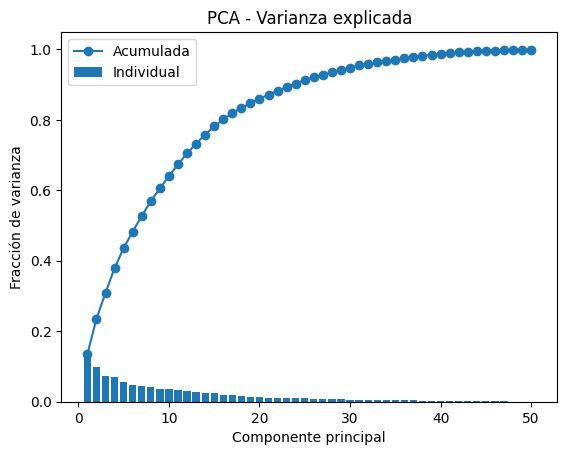

ValueError: Image size of 589x245271 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [14]:
pca = PCA(n_components=50)
pca.fit(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_exp = np.cumsum(exp_var)
k = len(exp_var)

# Varianza explicada
fig, ax = plt.subplots()
ax.bar(range(1, k+1), exp_var, label="Individual")
ax.plot(range(1, k+1), cum_exp, marker="o", label="Acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Fracción de varianza")
ax.set_title("PCA - Varianza explicada")
ax.legend()
plt.show()

# Proyección 2D
Z = pca.transform(X_scaled)
pc1, pc2 = Z[:,0], Z[:,1]

fig, ax = plt.subplots()
for c in np.unique(y):
    sel = y.values == c
    ax.scatter(pc1[sel], pc2[sel], s=35, alpha=0.8, label=f"Clase {c}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - Proyección 2D (PC1 vs PC2)")
ax.legend()
plt.show()

In [15]:
pca = PCA(n_components=min(25, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum()
print(f"Dimensión tras PCA: {X_pca.shape}, varianza explicada acumulada: {explained:.3f}")

Dimensión tras PCA: (23230, 25), varianza explicada acumulada: 0.913


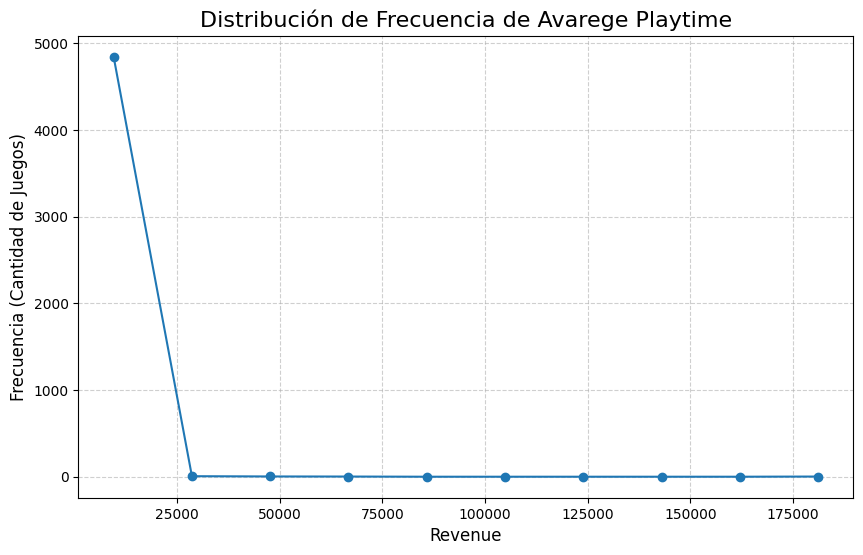

In [ ]:
condition = (df_encoded["median_playtime"] == 0)
indices_to_drop = df_encoded[condition].index
df_avg = df_encoded.drop(indices_to_drop)

counts, bin_edges = np.histogram(df_avg['median_playtime'], bins=10) 
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de línea
plt.plot(bin_centers, counts, marker='o', linestyle='-')

plt.title('Distribución de Frecuencia de Avarege Playtime', fontsize=16)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Juegos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

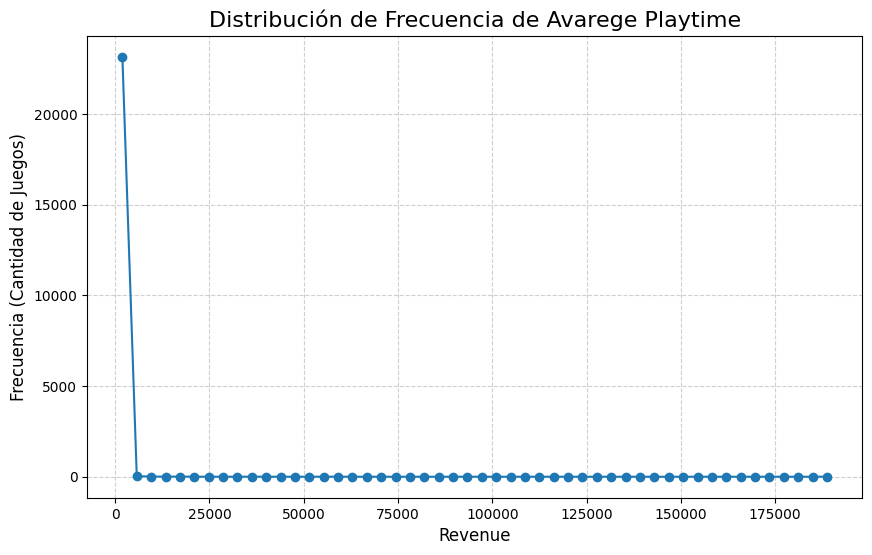

In [ ]:
condition = (df["average_playtime"] == 0)
indices_to_drop = df[condition].index
df_avg = df.drop(indices_to_drop)

counts, bin_edges = np.histogram(df_encoded['average_playtime'], bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de línea
plt.plot(bin_centers, counts, marker='o', linestyle='-')

plt.title('Distribución de Frecuencia de Avarege Playtime', fontsize=16)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Juegos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
print(df_encoded.columns)

Index(['english_t', 'publisher_Strategy First', 'publisher_infrequent_sklearn',
       'publisherclass_AAA', 'publisherclass_Hobbyist', 'publisherclass_Indie',
       'owners_100000-200000', 'owners_1000000-2000000', 'owners_20000-50000',
       'owners_200000-500000',
       ...
       'steamspy_tags_Wargame', 'steamspy_tags_Warhammer 40K',
       'steamspy_tags_Werewolves', 'steamspy_tags_Western',
       'steamspy_tags_Word Game', 'steamspy_tags_World War I',
       'steamspy_tags_World War II', 'steamspy_tags_Wrestling',
       'steamspy_tags_Zombies', 'steamspy_tags_e-sports'],
      dtype='object', length=407)


In [ ]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

revenues_por_genero = {}
for genero_col in columnas_generos:
    total_revenue = df_encoded[df_encoded[genero_col] == 1]['revenue'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    revenues_por_genero[nombre_limpio] = total_revenue

serie_revenues = pd.Series(revenues_por_genero)

C:\Users\alons\AppData\Local\Temp\ipykernel_19324\3104413571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')


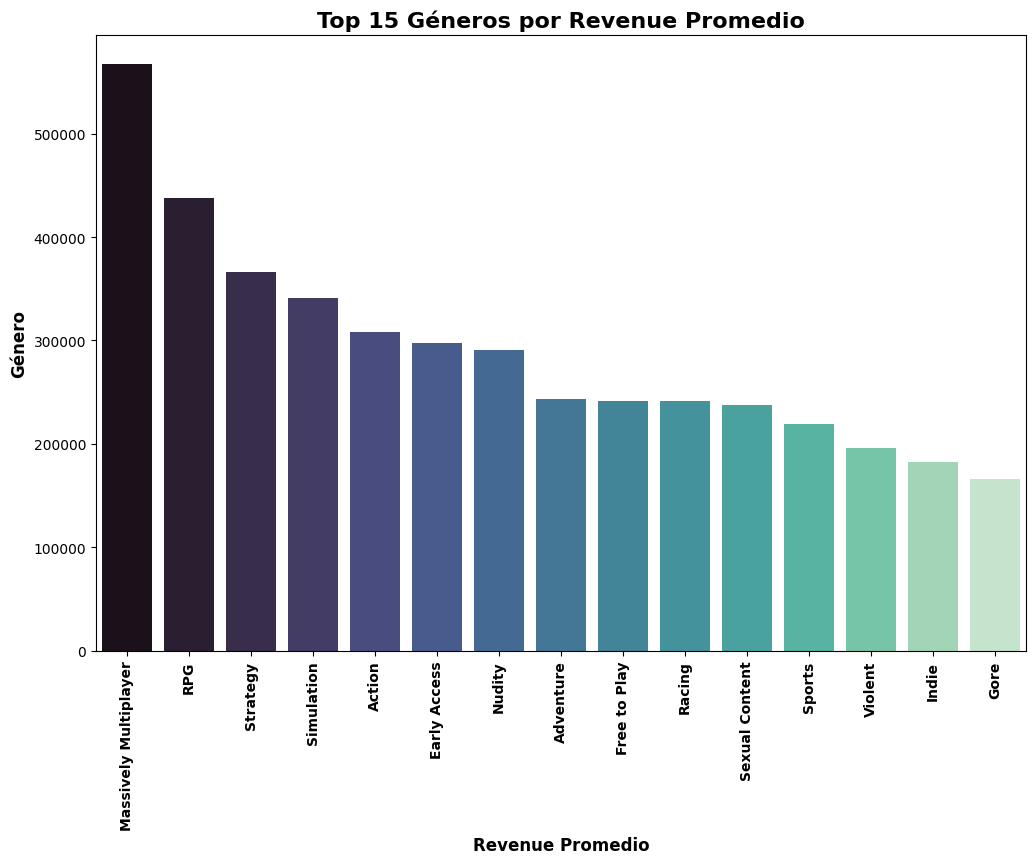

In [ ]:
top_generos = serie_revenues.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))

sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.title('Top 15 Géneros por Revenue Promedio', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontweight='bold')
plt.xlabel('Revenue Promedio', fontsize=12, fontweight='bold')
plt.ylabel('Género', fontsize=12, fontweight='bold')

plt.show()

In [ ]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

prices_por_genero = {}
for genero_col in columnas_generos:
    average_price = df_encoded[df_encoded[genero_col] == 1]['price'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    prices_por_genero[nombre_limpio] = average_price

serie_prices = pd.Series(prices_por_genero)

In [ ]:
top_generos = serie_prices.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.xticks(rotation=90, fontweight='bold')

plt.title('Top 15 Géneros por Precio Promedio', fontsize=16,fontweight='bold')
plt.xlabel('Género', fontsize=12, fontweight='bold')
plt.ylabel('Precio Promedio', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

C:\Users\alons\AppData\Local\Temp\ipykernel_19324\2608495637.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette='mako')


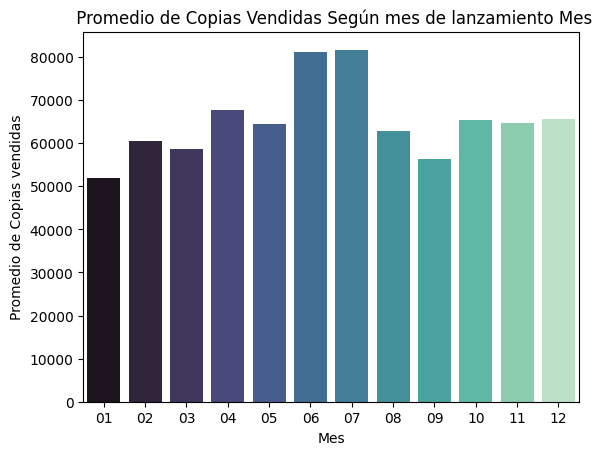

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [ ]:
df['month'] = df['release_date'].str.split('-').str[1]
data = df.groupby('month')["copiessold"].mean()

sns.barplot(x=data.index, y=data.values, palette='mako')
plt.xlabel("Mes")
plt.ylabel("Promedio de Copias vendidas")
plt.title(" Promedio de Copias Vendidas Según mes de lanzamiento Mes")
plt.show()

plt.figure(figsize=(12, 8))


C:\Users\alons\AppData\Local\Temp\ipykernel_19324\2893977007.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')


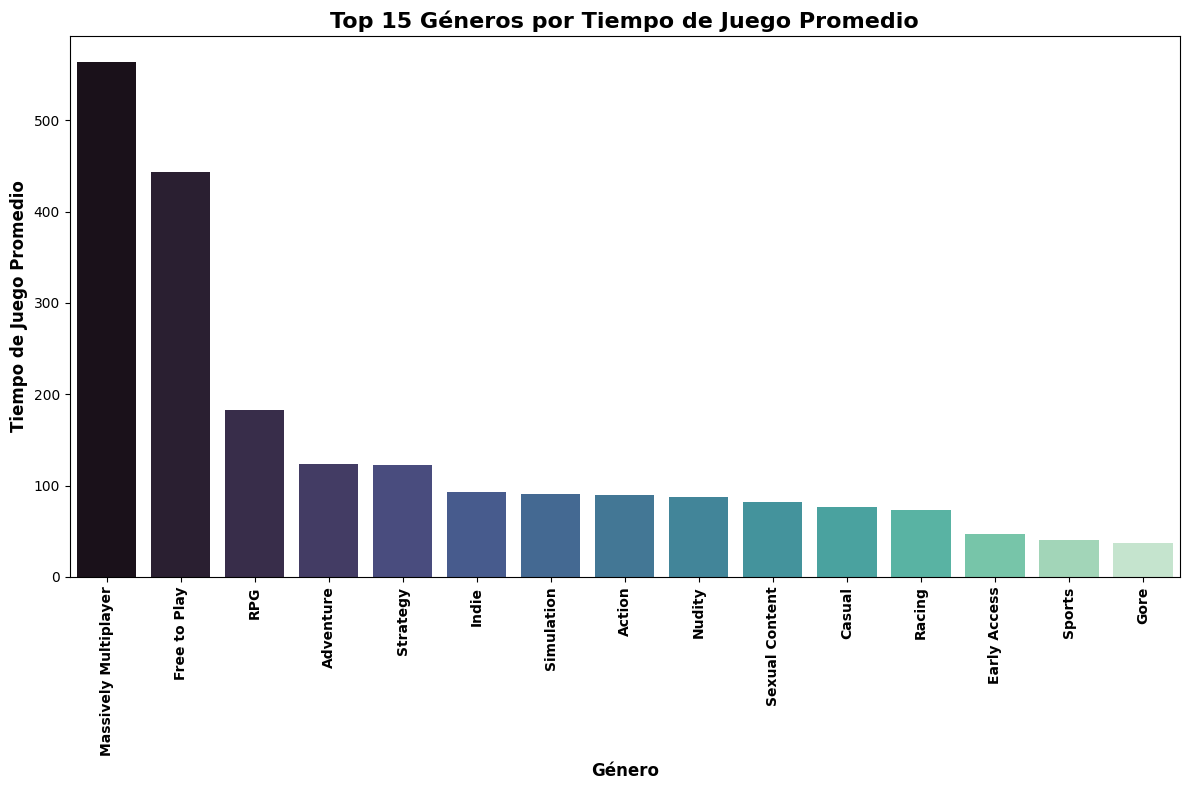

In [ ]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

prices_por_genero = {}
for genero_col in columnas_generos:
    average_price = df_encoded[df_encoded[genero_col] == 1]['average_playtime'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    prices_por_genero[nombre_limpio] = average_price

serie_prices = pd.Series(prices_por_genero)

top_generos = serie_prices.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.xticks(rotation=90, fontweight='bold')

plt.title('Top 15 Géneros por Tiempo de Juego Promedio', fontsize=16,fontweight='bold')
plt.xlabel('Género', fontsize=12, fontweight='bold')
plt.ylabel('Tiempo de Juego Promedio', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\alons\AppData\Local\Temp\ipykernel_19324\3460169952.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')


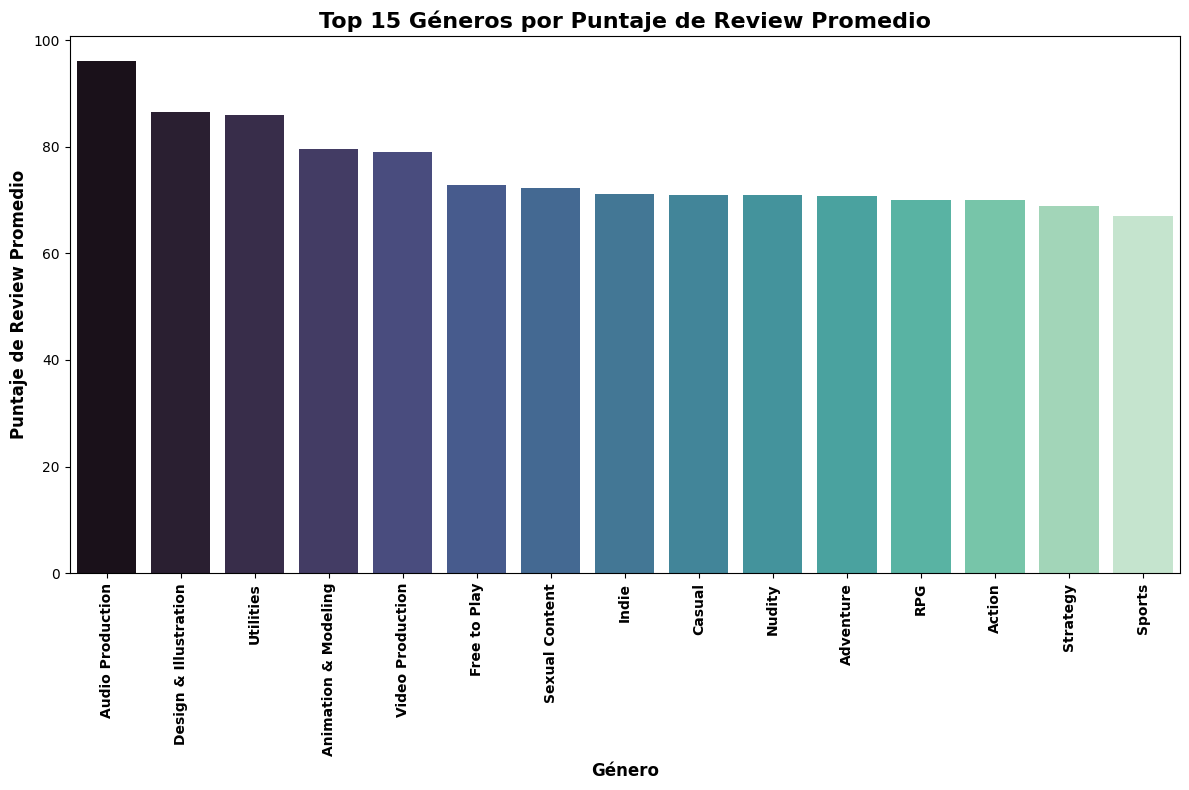

In [ ]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

prices_por_genero = {}
for genero_col in columnas_generos:
    average_price = df_encoded[df_encoded[genero_col] == 1]['reviewscore'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    prices_por_genero[nombre_limpio] = average_price

serie_prices = pd.Series(prices_por_genero)

top_generos = serie_prices.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.xticks(rotation=90, fontweight='bold')

plt.title('Top 15 Géneros por Puntaje de Review Promedio', fontsize=16,fontweight='bold')
plt.xlabel('Género', fontsize=12, fontweight='bold')
plt.ylabel('Puntaje de Review Promedio', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\alons\AppData\Local\Temp\ipykernel_19324\2219396351.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')


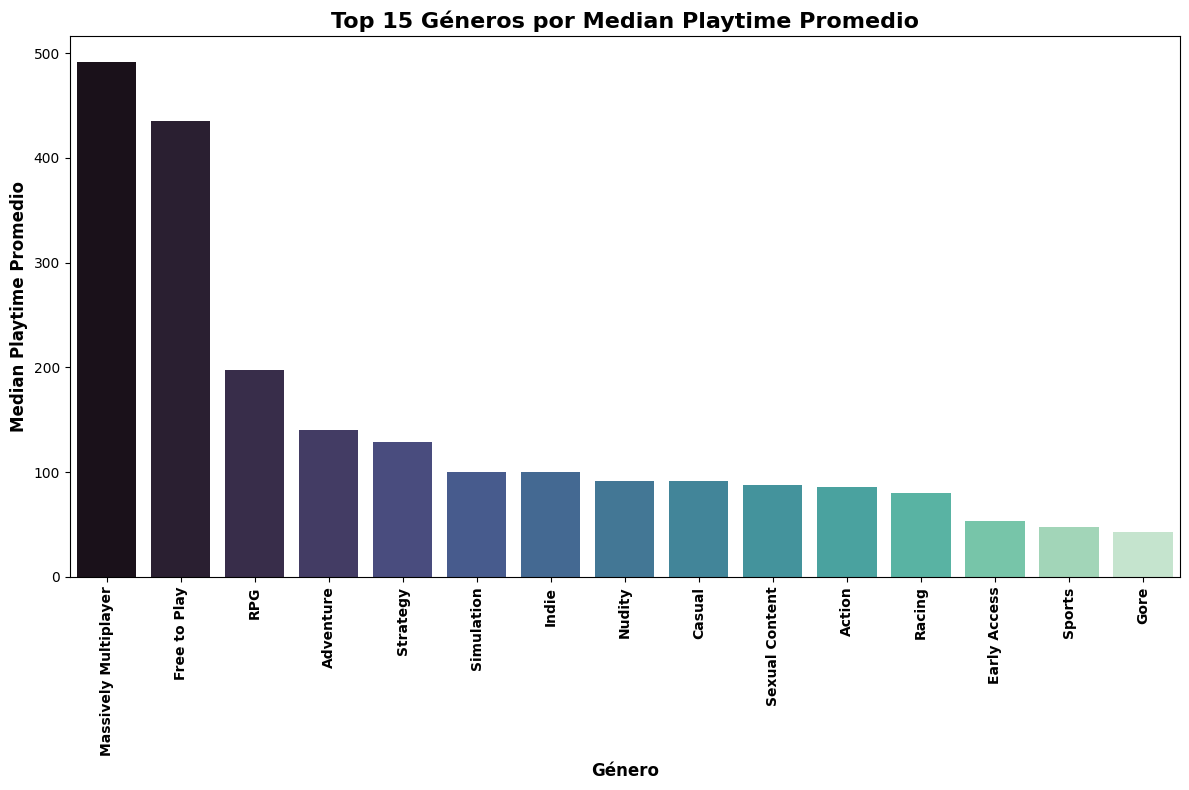

In [ ]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

prices_por_genero = {}
for genero_col in columnas_generos:
    average_price = df_encoded[df_encoded[genero_col] == 1]['median_playtime'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    prices_por_genero[nombre_limpio] = average_price

serie_prices = pd.Series(prices_por_genero)

top_generos = serie_prices.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.xticks(rotation=90, fontweight='bold')

plt.title('Top 15 Géneros por Median Playtime Promedio', fontsize=16,fontweight='bold')
plt.xlabel('Género', fontsize=12, fontweight='bold')
plt.ylabel('Median Playtime Promedio', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.cluster import DBSCAN, KMeans


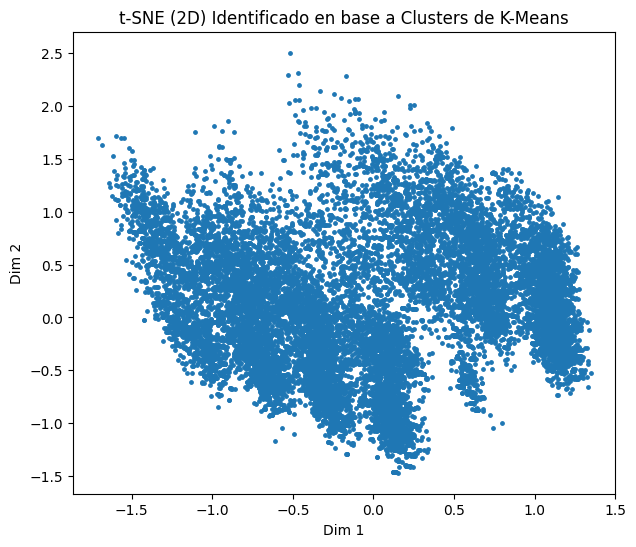

In [17]:
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], s=6)
plt.title("t-SNE (2D) Identificado en base a Clusters de K-Means")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

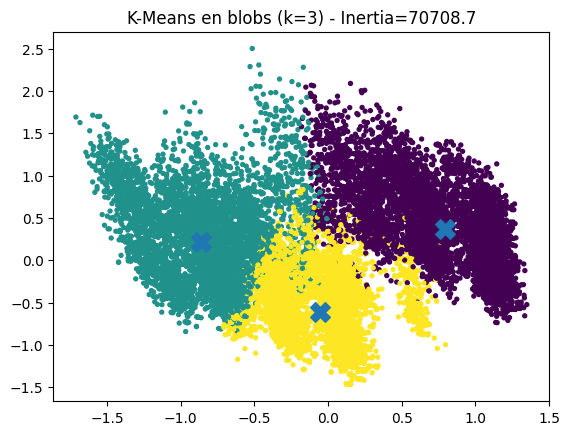

In [19]:
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = km.fit_predict(X_pca)
centers = km.cluster_centers_
inertia = km.inertia_

fig = plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, c=labels)
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)
plt.title(f"K-Means en blobs (k={k}) - Inertia={inertia:.1f}")
plt.show()

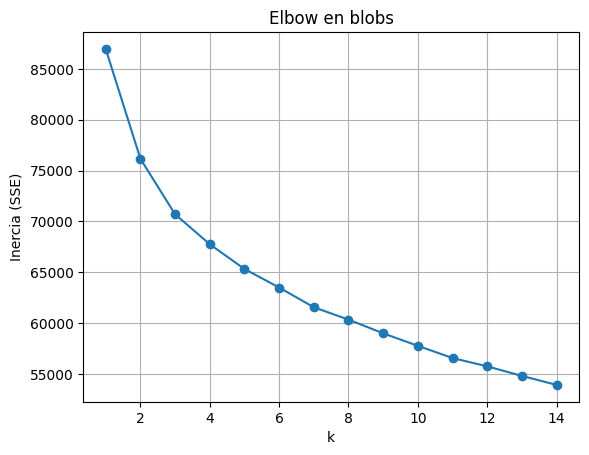

In [20]:
k_list = range(1, 15)
inertias = []

for k in k_list:
    km_ = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca)
    inertias.append(km_.inertia_)

fig = plt.figure()
plt.plot(list(k_list), inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inercia (SSE)")
plt.title("Elbow en blobs")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

k_list = range(2, 15)
silhouette_scores = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"Para k={k}, Coeficiente de Silueta: {score:.4f}")

Para k=2, Coeficiente de Silueta: 0.1191
Para k=3, Coeficiente de Silueta: 0.1040
Para k=4, Coeficiente de Silueta: 0.1015
Para k=5, Coeficiente de Silueta: 0.0967
Para k=6, Coeficiente de Silueta: 0.0832
Para k=7, Coeficiente de Silueta: 0.0804
Para k=8, Coeficiente de Silueta: 0.0758
Para k=9, Coeficiente de Silueta: 0.0777
Para k=10, Coeficiente de Silueta: 0.0731
Para k=11, Coeficiente de Silueta: 0.0751
Para k=12, Coeficiente de Silueta: 0.0835
Para k=13, Coeficiente de Silueta: 0.0746
Para k=14, Coeficiente de Silueta: 0.0753


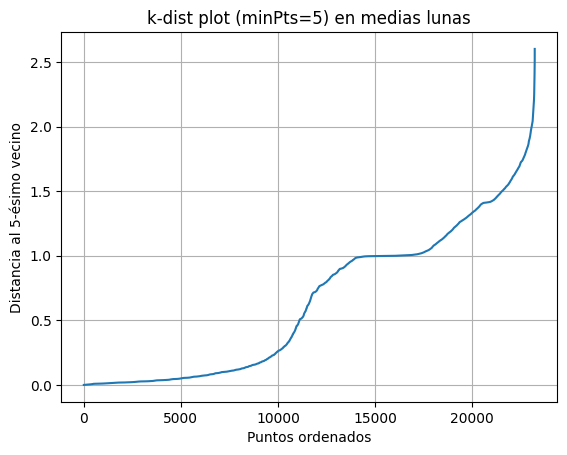

In [23]:
from sklearn.neighbors import NearestNeighbors

minPts = 5
nn = NearestNeighbors(n_neighbors=minPts).fit(X_pca)
dists, _ = nn.kneighbors(X_pca)
k_dists = np.sort(dists[:, -1])

fig = plt.figure()
plt.plot(np.arange(1, len(k_dists)+1), k_dists)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {minPts}-ésimo vecino")
plt.title(f"k-dist plot (minPts={minPts}) en medias lunas")
plt.grid(True)
plt.show()

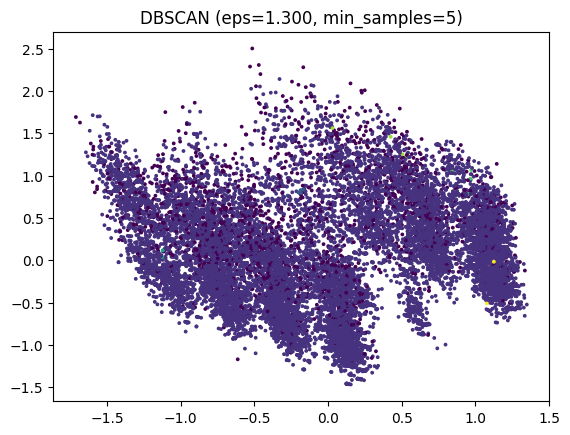

In [24]:
eps = 1.3
db = DBSCAN(eps=eps, min_samples=minPts)
labels_db = db.fit_predict(X_pca)

fig = plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=3, c=labels_db)
plt.title(f"DBSCAN (eps={eps:.3f}, min_samples={minPts})")
plt.show()


In [25]:
from sklearn.manifold import TSNE

tsne2 = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', max_iter=1000, random_state=42)
X_tsne2 = tsne2.fit_transform(X_pca)

In [26]:
print(y.dtype)
print(y.min(), y.max(), y.std())

int64
0 53550178 506730.0773762627


C:\Users\alons\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\alons\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


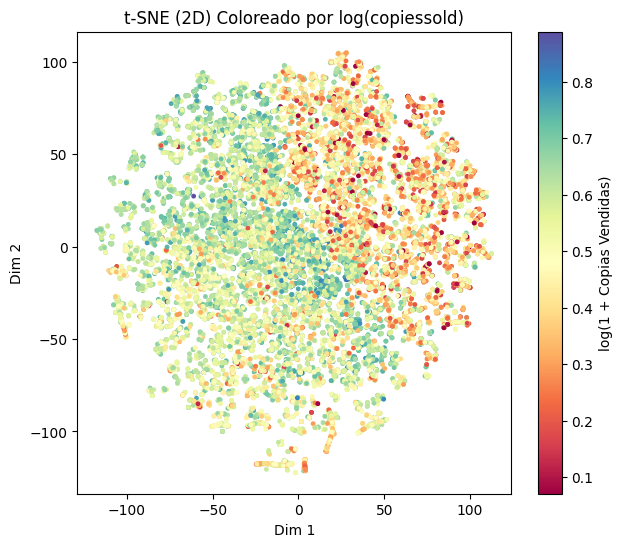

In [27]:
import numpy as np

y_log = np.log10(np.log10(y)) 
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_tsne2[:,0], X_tsne2[:,1], c=y_log, s=6, cmap='Spectral')

plt.colorbar(scatter, label='log(1 + Copias Vendidas)') 

plt.title("t-SNE (2D) Coloreado por log(copiessold)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [28]:
import plotly.express as px

fig = px.scatter(x=X_tsne2[:, 0], y=X_tsne2[:, 1], color=y_log)
fig.update_layout(
    title="PCA visualization of Custom Classification dataset",
    xaxis_title="First Principal Component",
    yaxis_title="Second Principal Component",
)
fig.show()

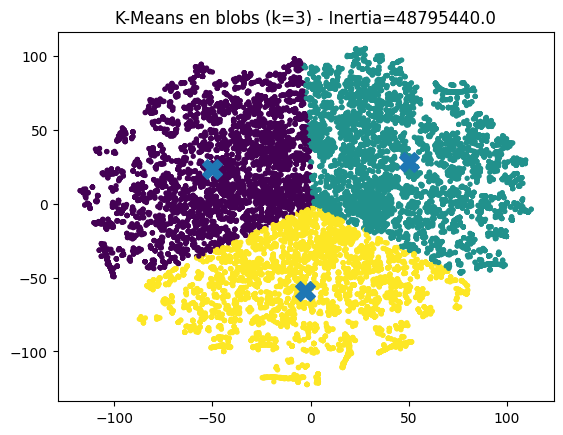

In [29]:
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = km.fit_predict(X_tsne2)
centers = km.cluster_centers_
inertia = km.inertia_

fig = plt.figure()
plt.scatter(X_tsne2[:,0], X_tsne2[:,1], s=8, c=labels)
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)
plt.title(f"K-Means en blobs (k={k}) - Inertia={inertia:.1f}")
plt.show()

In [ ]:
import umap

umap2 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap2 = umap2.fit_transform(X_pca)

C:\Users\alons\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

C:\Users\alons\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



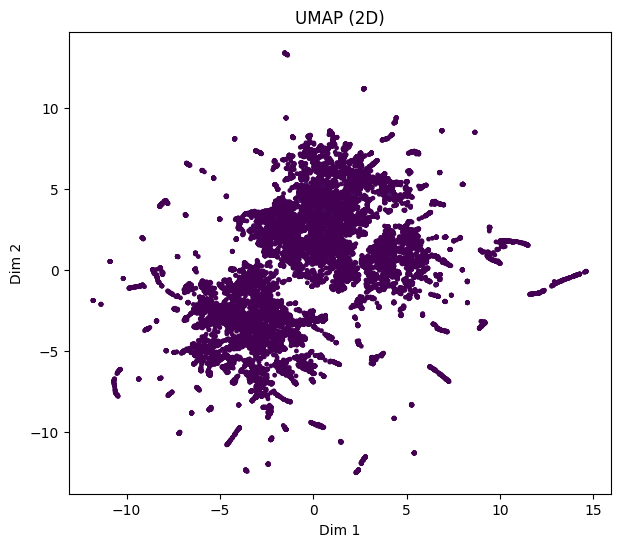

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(X_umap2[:,0], X_umap2[:,1], c=log_y, s=6)
plt.title("UMAP (2D)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()